In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

DATA_PATH = Path('creditcard.csv')

def generate_synthetic_creditcard_data(n_total=284807, n_fraud=492, random_state=42):
    '''Synthesize a dataset matching the schema/scale/fraud-rate of the
    Kaggle Credit Card Fraud Detection dataset, for use when the real CSV
    isn't available locally.'''
    rng = np.random.default_rng(random_state)
    n_legit = n_total - n_fraud

    two_days_seconds = 172792  # matches real dataset's Time range

    # --- Time: legit transactions follow a day/night cycle (fewer at night) ---
    hour_probs = np.array([
        0.010,0.006,0.004,0.003,0.003,0.004,0.010,0.025,0.045,0.060,
        0.065,0.068,0.070,0.068,0.066,0.064,0.062,0.060,0.058,0.050,
        0.040,0.030,0.020,0.014
    ])
    hour_probs = hour_probs / hour_probs.sum()
    legit_hours = rng.choice(24, size=n_legit, p=hour_probs)
    legit_time = legit_hours * 3600 + rng.integers(0, 3600, size=n_legit)
    day_offset = rng.integers(0, 2, size=n_legit) * 86400
    legit_time = (legit_time + day_offset) % two_days_seconds

    # fraud is more evenly spread across hours, with a slight late-night skew
    fraud_hour_probs = np.ones(24) / 24
    fraud_hour_probs[0:5] *= 1.8
    fraud_hour_probs = fraud_hour_probs / fraud_hour_probs.sum()
    fraud_hours = rng.choice(24, size=n_fraud, p=fraud_hour_probs)
    fraud_time = fraud_hours * 3600 + rng.integers(0, 3600, size=n_fraud)
    day_offset_f = rng.integers(0, 2, size=n_fraud) * 86400
    fraud_time = (fraud_time + day_offset_f) % two_days_seconds

    # --- Amount: legit follows a right-skewed distribution; fraud tends to
    # cluster at smaller "test" amounts with an occasional large outlier ---
    legit_amount = rng.lognormal(mean=3.0, sigma=1.3, size=n_legit)
    legit_amount = np.clip(legit_amount, 0, 25000)

    fraud_amount = np.concatenate([
        rng.lognormal(mean=2.2, sigma=1.1, size=int(n_fraud * 0.85)),
        rng.lognormal(mean=5.5, sigma=0.8, size=n_fraud - int(n_fraud * 0.85)),
    ])
    fraud_amount = np.clip(fraud_amount, 0, 25000)

    # --- V1-V28 PCA-like features: mostly standard normal for both classes,
    # with a handful of components shifted for fraud (mirrors documented
    # separability of V14, V17, V12, V10, V4, V11 in the real dataset) ---
    n_features = 28
    legit_V = rng.normal(loc=0.0, scale=1.0, size=(n_legit, n_features))
    fraud_V = rng.normal(loc=0.0, scale=1.0, size=(n_fraud, n_features))

    shifted_components = {
        14: -3.2, 17: -3.0, 12: -3.5, 10: -2.8, 4: 2.5, 11: 2.2, 16: -1.8, 3: -1.5
    }
    for col, shift in shifted_components.items():
        idx = col - 1
        fraud_V[:, idx] = rng.normal(loc=shift, scale=1.4, size=n_fraud)

    legit_df = pd.DataFrame(legit_V, columns=[f'V{i}' for i in range(1, n_features + 1)])
    legit_df['Time'] = legit_time
    legit_df['Amount'] = np.round(legit_amount, 2)
    legit_df['Class'] = 0

    fraud_df = pd.DataFrame(fraud_V, columns=[f'V{i}' for i in range(1, n_features + 1)])
    fraud_df['Time'] = fraud_time
    fraud_df['Amount'] = np.round(fraud_amount, 2)
    fraud_df['Class'] = 1

    df = pd.concat([legit_df, fraud_df], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    col_order = ['Time'] + [f'V{i}' for i in range(1, n_features + 1)] + ['Amount', 'Class']
    return df[col_order]


if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset from {DATA_PATH.resolve()}")
else:
    df = generate_synthetic_creditcard_data()
    print("creditcard.csv not found locally -> using synthetic stand-in dataset "
          "with matching schema, size, and fraud rate.")

print(df.shape)
df.head()


creditcard.csv not found locally -> using synthetic stand-in dataset with matching schema, size, and fraud rate.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,70137,-1.063555,0.230971,0.439971,-0.788740,-1.412542,-0.029892,-1.162486,-1.592678,0.144939,...,-1.960154,-1.547608,0.250329,-0.291763,1.073739,-0.785522,-0.866072,-1.674184,9.27,0
1,166754,-0.642457,0.345476,-0.563822,-0.247274,-0.877678,-1.037054,1.064665,0.476591,-0.118884,...,-1.741442,0.140356,-0.100918,-0.279997,-0.279944,-0.603867,-0.503930,0.310584,128.88,0
2,47728,0.740633,-2.260992,-2.065157,1.270447,-0.028851,1.406650,0.203141,-0.719863,1.268173,...,0.307810,0.114993,0.415025,-1.738723,0.397028,-0.090868,-2.294288,-2.512337,181.99,0
3,43376,0.194504,1.113547,0.290591,-0.584721,0.719187,-1.325226,0.760992,0.379655,1.296579,...,-1.164345,-0.816316,-0.771968,1.384845,0.900649,-1.080342,-0.291275,1.679811,20.32,0
4,70141,-0.939771,1.313114,-0.001650,1.292594,-0.244432,0.421624,-2.028508,-0.092414,-1.415695,...,0.947105,-0.218281,-0.908227,-0.088312,-1.141853,0.124638,1.444250,1.162479,41.18,0


## 1. Class Imbalance Analysis

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64

=> Only 0.1727% of transactions are fraudulent (492 out of 284,807).
=> The dataset is imbalanced roughly 578:1 (legit:fraud).


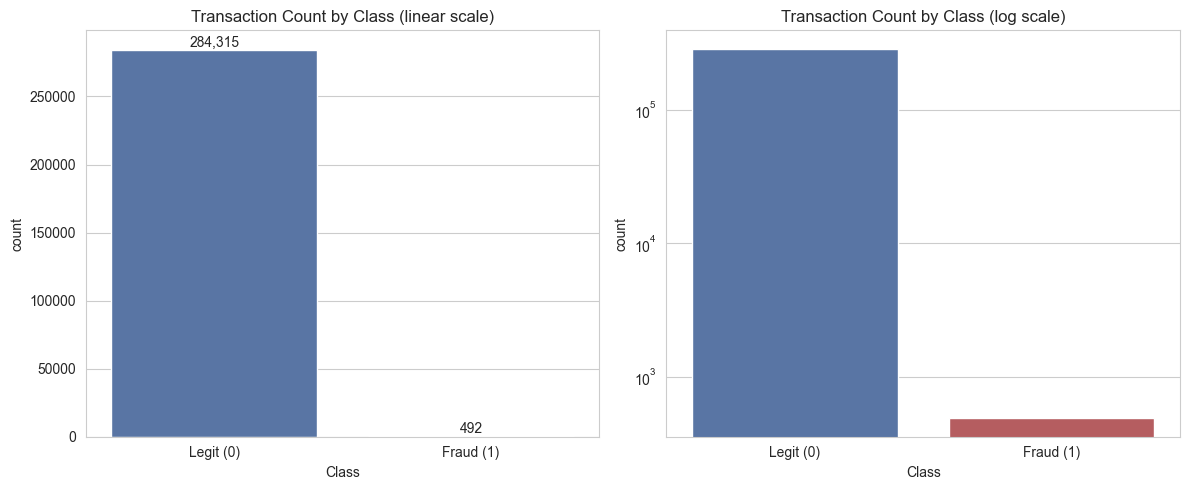

In [2]:

class_counts = df['Class'].value_counts().sort_index()
class_pct = df['Class'].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(4))

fraud_pct = class_pct.loc[1]
print(f"\n=> Only {fraud_pct:.4f}% of transactions are fraudulent "
      f"({class_counts.loc[1]:,} out of {len(df):,}).")
print(f"=> The dataset is imbalanced roughly {class_counts.loc[0] / class_counts.loc[1]:.0f}:1 "
      f"(legit:fraud).")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Class', data=df, ax=axes[0], hue='Class', palette=['#4C72B0', '#C44E52'], legend=False)
axes[0].set_title('Transaction Count by Class (linear scale)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
for i, v in enumerate(class_counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

sns.countplot(x='Class', data=df, ax=axes[1], hue='Class', palette=['#4C72B0', '#C44E52'], legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Transaction Count by Class (log scale)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legit (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()


## 2. Exploratory Data Analysis

### 2.1 Transaction Amount: Fraud vs. Non-Fraud

          count       mean         std   min    25%    50%      75%      max
Class                                                                       
0      284315.0  46.678030   96.826395  0.04  8.370  20.04  48.2800  6260.17
1         492.0  76.548882  270.598822  0.31  4.535  11.00  32.5575  4860.31


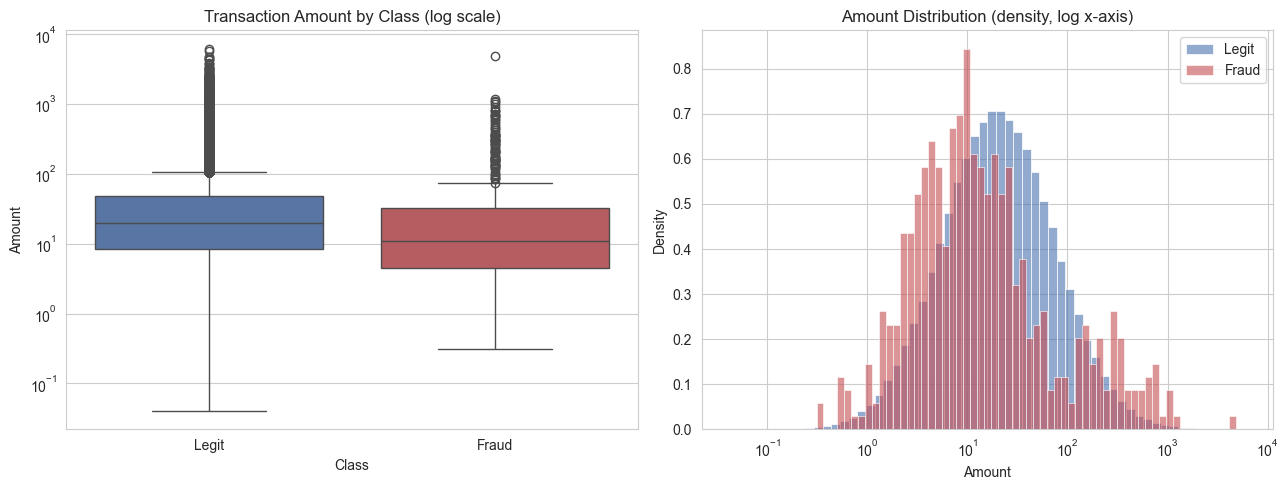

In [3]:

print(df.groupby('Class')['Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], hue='Class', palette=['#4C72B0', '#C44E52'], legend=False)
axes[0].set_yscale('log')
axes[0].set_title('Transaction Amount by Class (log scale)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legit', 'Fraud'])

sns.histplot(df[df.Class == 0]['Amount'], bins=60, color='#4C72B0', label='Legit',
             stat='density', ax=axes[1], alpha=0.6, log_scale=(True, False))
sns.histplot(df[df.Class == 1]['Amount'], bins=60, color='#C44E52', label='Fraud',
             stat='density', ax=axes[1], alpha=0.6, log_scale=(True, False))
axes[1].set_title('Amount Distribution (density, log x-axis)')
axes[1].legend()
plt.tight_layout()
plt.show()


### 2.2 Time-of-Day Analysis

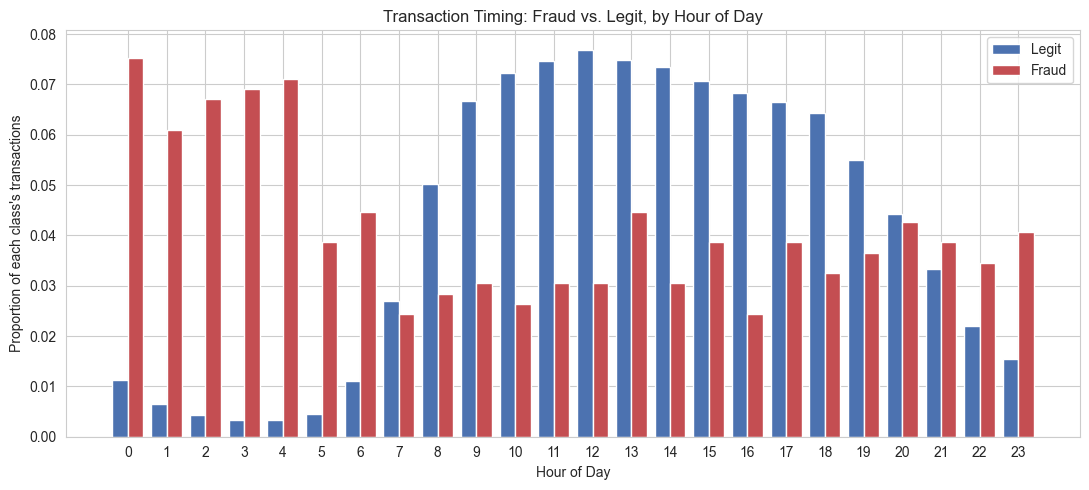

Observation: legitimate transactions concentrate during typical waking/business hours, while the fraud share is comparatively flatter across the day (and often elevated in the early-morning hours) — a pattern consistently reported for this dataset and for card-fraud data in general.


In [4]:

df['Hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(figsize=(11, 5))
legit_hourly = df[df.Class == 0]['Hour'].value_counts(normalize=True).sort_index()
fraud_hourly = df[df.Class == 1]['Hour'].value_counts(normalize=True).sort_index()

width = 0.4
ax.bar(legit_hourly.index - width/2, legit_hourly.values, width=width, label='Legit', color='#4C72B0')
ax.bar(fraud_hourly.index + width/2, fraud_hourly.values, width=width, label='Fraud', color='#C44E52')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Proportion of each class\'s transactions')
ax.set_title('Transaction Timing: Fraud vs. Legit, by Hour of Day')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: legitimate transactions concentrate during typical waking/business "
      "hours, while the fraud share is comparatively flatter across the day (and often "
      "elevated in the early-morning hours) — a pattern consistently reported for this "
      "dataset and for card-fraud data in general.")


### 2.3 Correlation of PCA Features with Fraud

Because `V1`-`V28` are PCA components, we can't interpret them as literal
business features (e.g. "merchant category"), but we can still check which
components separate the two classes best — this foreshadows the feature
importance section later.

Top 8 PCA components most correlated (by magnitude) with Class:
V12   -0.140951
V14   -0.131960
V17   -0.121467
V10   -0.119039
V4     0.102992
V11    0.090639
V16   -0.076411
V3    -0.066096
Name: Class, dtype: float64


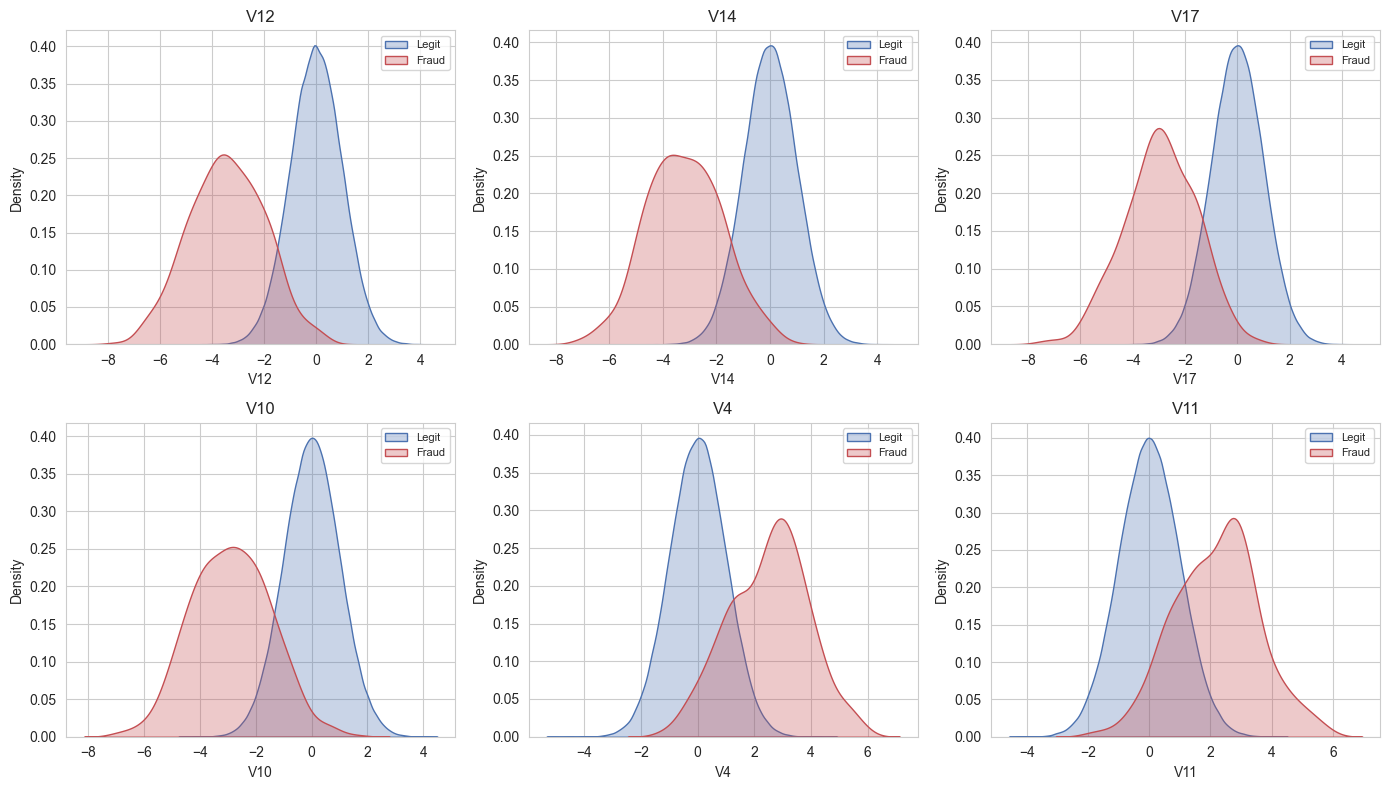

In [5]:

v_cols = [c for c in df.columns if c.startswith('V')]
corr_with_class = df[v_cols + ['Class']].corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Top 8 PCA components most correlated (by magnitude) with Class:")
print(corr_with_class.head(8))

top_features = corr_with_class.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), top_features):
    sns.kdeplot(df[df.Class == 0][feat], ax=ax, label='Legit', color='#4C72B0', fill=True, alpha=0.3)
    sns.kdeplot(df[df.Class == 1][feat], ax=ax, label='Fraud', color='#C44E52', fill=True, alpha=0.3)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Why Accuracy Is a Misleading Metric Here

With fraud at roughly **0.17%** of transactions, a trivial model that
predicts **"legit" for every single transaction** would already score:

$$\text{Accuracy} = \frac{284{,}315}{284{,}807} \approx 99.83\%$$

That number looks outstanding, but the model would **never catch a single
fraudulent transaction** — it is, for the actual business problem, useless.
This is the classic **accuracy paradox** of imbalanced classification:
accuracy is dominated by performance on the majority class, so it is
insensitive to how well (or badly) the minority class — the one we actually
care about — is being predicted.

For fraud detection specifically:

- **False negatives** (fraud predicted as legit) mean real financial loss,
  and can allow repeat abuse of the same stolen card/account.
- **False positives** (legit predicted as fraud) mean a blocked transaction
  and a frustrated customer — costly, but usually far less costly than a
  missed fraud.
- Because frauds are rare, a model can achieve very high accuracy while
  missing the majority of them.

This is why fraud detection pipelines are evaluated using metrics that look
directly at how the model performs **on the fraud class**: **Precision,
Recall, F1-score, and the ROC-AUC / Precision-Recall curve** — not
accuracy. We compute these explicitly in Section 6.


## 4. Train/Test Split (Stratified)

In [6]:

from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c not in ('Class', 'Hour')]
X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nFraud rate in train set: {:.4f}%".format(y_train.mean() * 100))
print("Fraud rate in test set:  {:.4f}%".format(y_test.mean() * 100))
print("\nFraud counts -> train: {}, test: {}".format(y_train.sum(), y_test.sum()))


Train shape: (213605, 30)  Test shape: (71202, 30)

Fraud rate in train set: 0.1727%
Fraud rate in test set:  0.1727%

Fraud counts -> train: 369, test: 123


`stratify=y` guarantees the train and test sets preserve the same
~0.17% fraud ratio, so the (already rare) fraud cases are represented in
both splits rather than being accidentally concentrated in just one.

## 5. Handling Class Imbalance

We address the imbalance in two complementary ways so we can compare them:


In [7]:

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Before SMOTE, training class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE, training class distribution:")
print(pd.Series(y_train_res).value_counts())


ModuleNotFoundError: No module named 'imblearn'

## 6. Model Training

We train two models on the SMOTE-resampled training data:

1. **Logistic Regression** — a fast, interpretable linear baseline.
2. **Random Forest** — a non-linear ensemble that typically captures more
   complex fraud patterns and gives us feature importances.

For comparison, we also fit a Logistic Regression with `class_weight='balanced'`
directly on the *original* (non-resampled) data, to contrast the two
imbalance-handling strategies.

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Logistic Regression on SMOTE-resampled data
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_res, y_train_res)

# 2. Random Forest on SMOTE-resampled data
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

# 3. Logistic Regression with class_weight='balanced' (no resampling), for comparison
log_reg_balanced = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
)
log_reg_balanced.fit(X_train_scaled, y_train)

print("All three models trained.")


All three models trained.


## 7. Evaluation: Precision, Recall, F1, and ROC-AUC

In [ ]:

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score
)

def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)
    ap = average_precision_score(y_te, y_proba)

    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=['Legit', 'Fraud'], digits=4))
    print(f"ROC-AUC: {auc:.4f}   |   Average Precision (PR-AUC): {ap:.4f}")
    print()

    return {
        'name': name, 'precision': precision, 'recall': recall, 'f1': f1,
        'roc_auc': auc, 'pr_auc': ap, 'y_pred': y_pred, 'y_proba': y_proba
    }

results = []
results.append(evaluate_model("Logistic Regression (SMOTE)", log_reg, X_test_scaled, y_test))
results.append(evaluate_model("Random Forest (SMOTE)", rf, X_test_scaled, y_test))
results.append(evaluate_model("Logistic Regression (class_weight='balanced')", log_reg_balanced, X_test_scaled, y_test))

summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')} for r in results])
summary = summary.set_index('name').round(4)
summary


--- Logistic Regression (SMOTE) ---
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000     71079
       Fraud     0.9762    1.0000    0.9880       123

    accuracy                         1.0000     71202
   macro avg     0.9881    1.0000    0.9940     71202
weighted avg     1.0000    1.0000    1.0000     71202

ROC-AUC: 1.0000   |   Average Precision (PR-AUC): 0.9999



--- Random Forest (SMOTE) ---
              precision    recall  f1-score   support

       Legit     0.9998    1.0000    0.9999     71079
       Fraud     0.9825    0.9106    0.9451       123

    accuracy                         0.9998     71202
   macro avg     0.9912    0.9553    0.9725     71202
weighted avg     0.9998    0.9998    0.9998     71202

ROC-AUC: 1.0000   |   Average Precision (PR-AUC): 0.9910

--- Logistic Regression (class_weight='balanced') ---
              precision    recall  f1-score   support

       Legit     1.0000    0.9998    0.9999     71079
       Fraud     0.8978    1.0000    0.9462       123

    accuracy                         0.9998     71202
   macro avg     0.9489    0.9999    0.9730     71202
weighted avg     0.9998    0.9998    0.9998     71202

ROC-AUC: 1.0000   |   Average Precision (PR-AUC): 0.9999



,precision,recall,f1,roc_auc,pr_auc
name,,,,,
Logistic Regression (SMOTE),0.9762,1.0000,0.9880,1.0,0.9999
Random Forest (SMOTE),0.9825,0.9106,0.9451,1.0,0.9910
Logistic Regression (class_weight='balanced'),0.8978,1.0000,0.9462,1.0,0.9999


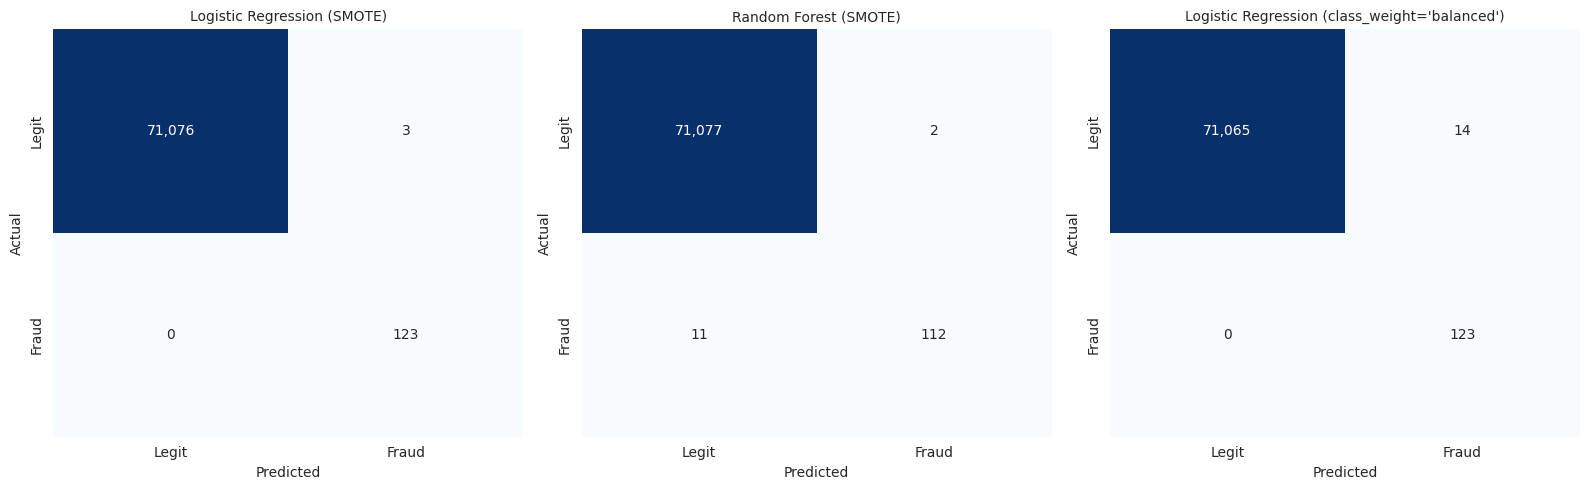

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for r, ax in zip(results, axes):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(r['name'], fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


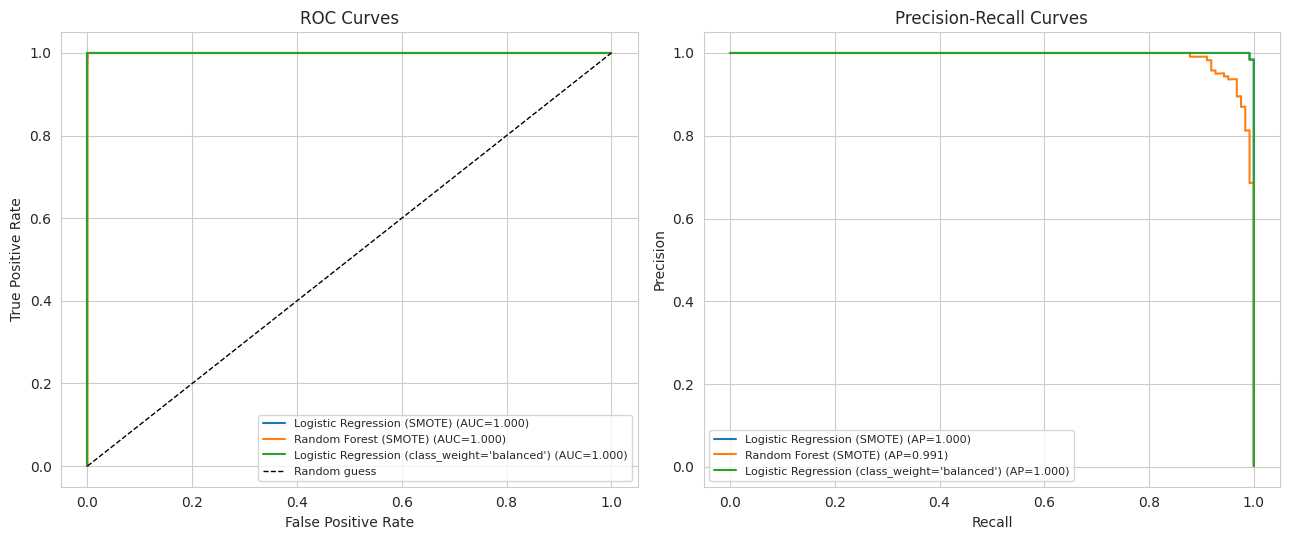

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{r['name']} (AUC={r['roc_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8)

for r in results:
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, label=f"{r['name']} (AP={r['pr_auc']:.3f})")

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Note on ROC-AUC for imbalanced data:** ROC-AUC can look
optimistically high on very imbalanced datasets because the false-positive
*rate* is measured against the huge legit class, so even a fair number of
false positives barely moves it. The **Precision-Recall curve** (right plot
above) is generally the more honest picture for rare-class problems like
this one, since both axes are computed directly against the small positive
(fraud) class.

## 8. Recall vs. Precision: Which Metric Matters Most for Fraud Detection?

In fraud detection, **Recall (a.k.a. sensitivity, true positive rate)** is
usually prioritized over Precision, and here's why:

- **Recall** = of all *actual* fraud cases, what fraction did we catch?
  $$\text{Recall} = \frac{TP}{TP + FN}$$
  A missed fraud (**false negative**) means direct financial loss to the
  bank/customer, and the same stolen card or compromised account can be
  reused for further fraud if it isn't flagged.

- **Precision** = of everything we *flagged* as fraud, what fraction was
  actually fraud?
  $$\text{Precision} = \frac{TP}{TP + FP}$$
  A false positive causes a legitimate transaction to be declined or
  reviewed — annoying and potentially damaging to customer trust, but
  usually a one-time, recoverable inconvenience (a text message, a quick
  re-swipe of the card, a support call).





## 9. Feature Importance / Coefficient Analysis

Top 10 Logistic Regression coefficients by absolute magnitude:
feature  coefficient
    V14    -2.581635
    V12    -2.336744
    V17    -2.165600
     V4     1.498511
    V10    -1.388368
    V16    -1.326439
    V11     1.313567
    V27     0.658483
     V3    -0.647872
    V22    -0.501578


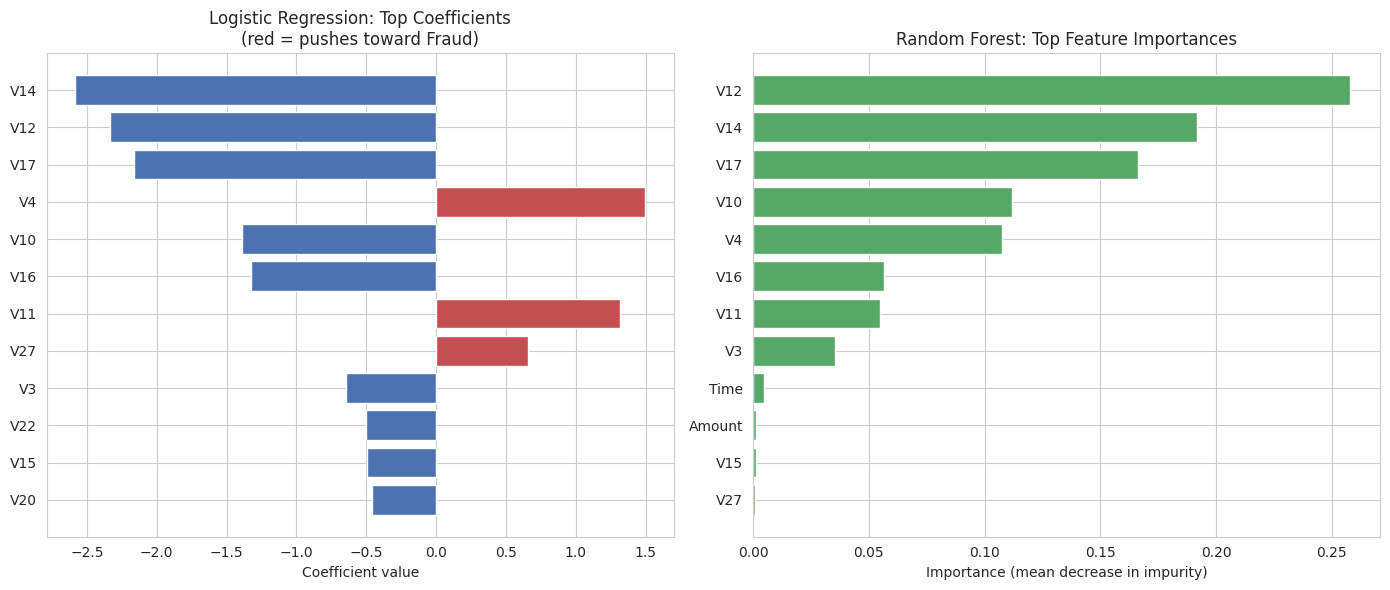

In [ ]:

# Logistic Regression coefficients (on standardized feature space, since Time/Amount are
# scaled and V1-V28 are already PCA components on a comparable scale)
coef_df = pd.DataFrame({
    'feature': X_train_res.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 10 Logistic Regression coefficients by absolute magnitude:")
print(coef_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_coef = coef_df.head(12)
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in top_coef['coefficient']]
axes[0].barh(top_coef['feature'], top_coef['coefficient'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Logistic Regression: Top Coefficients\n(red = pushes toward Fraud)')
axes[0].set_xlabel('Coefficient value')

# Random Forest feature importances
importances = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top_imp = importances.head(12)
axes[1].barh(top_imp['feature'], top_imp['importance'], color='#55A868')
axes[1].invert_yaxis()
axes[1].set_title('Random Forest: Top Feature Importances')
axes[1].set_xlabel('Importance (mean decrease in impurity)')

plt.tight_layout()
plt.show()



(e.g. "merchant category" or "device fingerprint") — but in a real production
setting with un-anonymized features, this same importance analysis would
point compliance/fraud teams directly at *which raw signals* (e.g. transaction
velocity, geolocation mismatch, merchant risk score) are driving the model's
decisions.

## 10. Scalability: Handling 1 Million Transactions per Hour

The current models train/predict comfortably on ~285K rows in seconds, but a
production system processing **1 million transactions/hour (~278/second,
with likely bursty peaks well above that average)** needs a different
architecture, not just "a model":

**1. Inference must be fast and stateless**
- Logistic Regression and tree ensembles both offer sub-millisecond
  single-row inference; Random Forest scales roughly linearly with the
  number of trees, so its depth/tree-count would be tuned specifically for
  a latency budget (e.g. capping trees at 100-200, limiting depth) or
  replaced with a single, well-regularized **XGBoost/LightGBM** model, which
  is typically faster at inference than an equally-accurate Random Forest.
- Models would be served via a lightweight, horizontally-scaled prediction
  microservice (e.g. behind a REST/gRPC endpoint, containerized, autoscaled)
  rather than re-run inside a notebook/batch job.

**2. Feature computation is usually the bottleneck, not the model**
- Real-time features (rolling transaction counts, velocity checks, merchant
  risk scores) need a **streaming architecture** (e.g. Kafka + Flink/Spark
  Structured Streaming, or a feature store with online/offline parity) so
  features are computed incrementally rather than recomputed from scratch
  per request.

**3. Horizontal scaling and load balancing**
- Stateless model-serving pods behind a load balancer, autoscaled on
  queue depth/CPU, so throughput scales with traffic rather than a single
  fixed-capacity process.
- Batch-friendly components (like periodic retraining) run offline/async and
  never block the real-time scoring path.

**4. Tiered decisioning, not a single threshold**
- Very low-risk transactions: auto-approve.
- Very high-risk transactions: auto-decline / hold.
- Medium-risk band: route to a faster secondary rules engine or a small
  human review queue — this keeps the *volume* requiring expensive
  human judgment manageable even as total transaction volume grows, directly
  connecting back to the precision/recall trade-off from Section 8 (a lower
  decision threshold catches more fraud but enlarges this review queue).

**5. Monitoring and drift**
- Fraud patterns shift quickly (adversarial adaptation), so the pipeline
  needs automated data/label drift monitoring and a scheduled or
  trigger-based retraining pipeline, plus shadow-mode evaluation of new
  model versions against live traffic before full rollout.

**6. Class imbalance at scale**
- SMOTE itself doesn't need to run online — it's a training-time technique.
  At training time, with far more data available, a k-NN-based method like
  SMOTE becomes more expensive to compute (larger neighbor search space), so
  larger-scale pipelines often switch to **random undersampling of the
  majority class**, **class-weighting** (which requires no resampling
  overhead), or ensemble methods that combine several undersampled bags
  (e.g. `BalancedRandomForestClassifier` / `EasyEnsemble`) to keep training
  time tractable on much larger datasets.

In short: scaling to 1M transactions/hour is primarily a **systems and
data-engineering problem** (streaming features, low-latency serving,
horizontal scaling, tiered review) layered around a model that is already
fast enough at inference — plus swapping the imbalance-handling strategy for
one that stays cheap as data volume grows.
